# 🛡️ AnomalyGuard — Model Training
Trains **Isolation Forest** + **Autoencoder** and saves models to `/models`


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)
print('✅ Imports done')

✅ Imports done


## Step 1 — Load Data

In [2]:
df = pd.read_csv('../data/creditcard.csv')
print(f'Shape  : {df.shape}')
print(f'Normal : {(df["Class"]==0).sum():,}')
print(f'Fraud  : {(df["Class"]==1).sum():,}')
df.head(3)

Shape  : (284807, 31)
Normal : 284,315
Fraud  : 492


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## Step 2 — Scale Features

In [3]:
features = [c for c in df.columns if c != 'Class']
X = df[features].values
y = df['Class'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
print(f'✅ Scaler saved | X_scaled shape: {X_scaled.shape}')

✅ Scaler saved | X_scaled shape: (284807, 30)


## Step 3 — Train Isolation Forest

In [4]:
fraud_ratio = float(y.sum()) / len(y)
print(f'Fraud ratio (contamination): {fraud_ratio:.5f}')

iso = IsolationForest(contamination=fraud_ratio, random_state=42, n_jobs=-1)  # n_jobs=-1 = use all CPU cores
iso.fit(X_scaled)

joblib.dump(iso, MODELS_DIR / 'isolation_forest.pkl')
print('✅ Isolation Forest saved')

Fraud ratio (contamination): 0.00173
✅ Isolation Forest saved


## Step 4 — Train Autoencoder

| Activation | Range   | Main Use            | Problem            |
| ---------- | ------- | ------------------- | ------------------ |
| Sigmoid    | 0 to 1  | Binary output       | Vanishing gradient |
| Tanh       | -1 to 1 | Older hidden layers | Vanishing gradient |
| ReLU       | 0 to ∞  | Hidden layers       | Dying ReLU         |
| Leaky ReLU | -∞ to ∞ | Better ReLU         | Slight complexity  |
| Softmax    | 0 to 1  | Multi-class output  | Expensive          |


# Modern Deep Learning Rule
| Layer              | Common Activation |
| ------------------ | ----------------- |
| Hidden layers      | ReLU              |
| Binary output      | Sigmoid           |
| Multi-class output | Softmax           |


In [5]:
# Define autoencoder inline — no import needed
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_dim=X_scaled.shape[1]),
    tf.keras.layers.Dense(8,  activation='relu'), #bottle neck or compress layer
    tf.keras.layers.Dense(16, activation='relu'), #decoder layer
    tf.keras.layers.Dense(X_scaled.shape[1], activation='linear'), # linear activation means original values doesnot need to make it diff
], name='autoencoder')

In [6]:
model.compile(optimizer='adam', loss='mse')

# Train ONLY on normal transactions — no fraud labels used!
X_normal = X_scaled[y == 0] 
print(f'Training on {len(X_normal):,} normal transactions (no fraud labels used)')

Training on 284,315 normal transactions (no fraud labels used)


In [7]:
model.summary()

Model: "autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                496       
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 16)                144       
                                                                 
 dense_3 (Dense)             (None, 30)                510       
                                                                 
Total params: 1,286
Trainable params: 1,286
Non-trainable params: 0
_________________________________________________________________


In [8]:
# model.fit(X_normal, X_normal)
#           input     target  ← SAME thing!
# "Given this input, reconstruct the same input back"

In [9]:
model.fit(X_normal, X_normal, epochs=20, batch_size=256, validation_split=0.1, verbose=1) #epochs means to pass dataset multiple times, here 20 means whole dataset will pass 20 times, batch size means first 256 samples will pass then rest 256 , i 1st256 foreward pass, calculate loss, backpropogation, update wt, next 256, validation split means: Use 10% data for validation

model.save(MODELS_DIR / 'autoencoder.h5')
print('\n✅ Autoencoder saved')

Epoch 1/20
1000/1000 [==============================] - 11s 7ms/step - loss: 0.7067 - val_loss: 0.5969
Epoch 2/20
1000/1000 [==============================] - 6s 6ms/step - loss: 0.5341 - val_loss: 0.5312
Epoch 3/20
1000/1000 [==============================] - 6s 6ms/step - loss: 0.4892 - val_loss: 0.5062
Epoch 4/20
1000/1000 [==============================] - 5s 5ms/step - loss: 0.4682 - val_loss: 0.4878
Epoch 5/20
1000/1000 [==============================] - 5s 5ms/step - loss: 0.4528 - val_loss: 0.4684
Epoch 6/20
1000/1000 [==============================] - 6s 6ms/step - loss: 0.4408 - val_loss: 0.4576
Epoch 7/20
1000/1000 [==============================] - 8s 8ms/step - loss: 0.4325 - val_loss: 0.4528
Epoch 8/20
1000/1000 [==============================] - 8s 8ms/step - loss: 0.4282 - val_loss: 0.4476
Epoch 9/20
1000/1000 [==============================] - 17s 17ms/step - loss: 0.4253 - val_loss: 0.4460
Epoch 10/20
1000/1000 [==============================] - 15s 15ms/step - loss: 

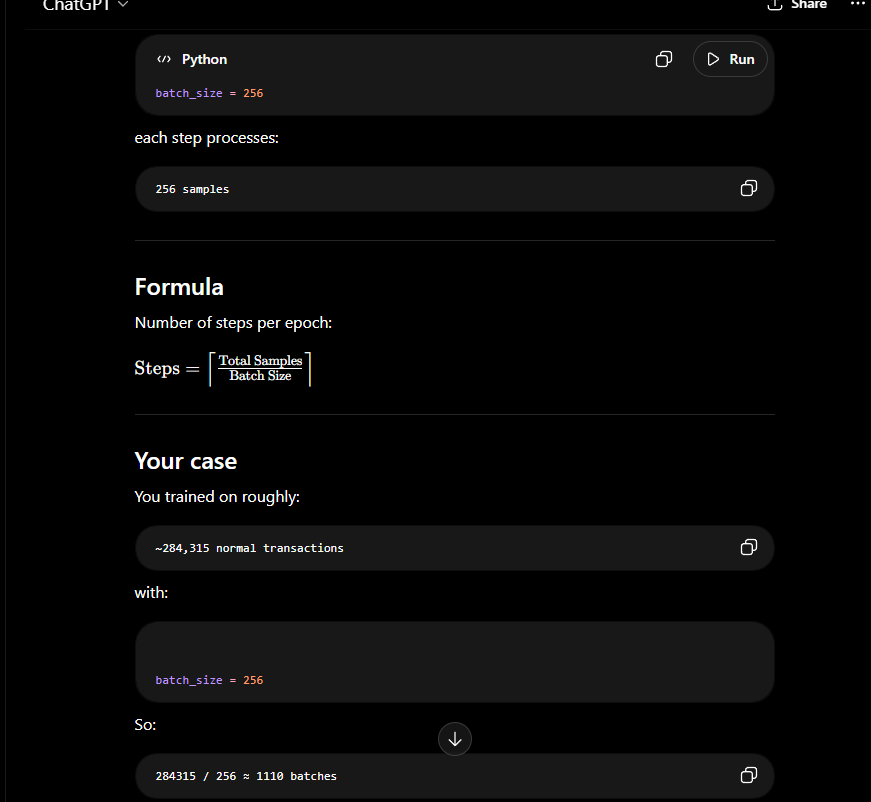

## Step 5 — Compute Anomaly Threshold

In [10]:
recon     = model.predict(X_normal, verbose=1)

8885/8885 [==============================] - 20s 2ms/step


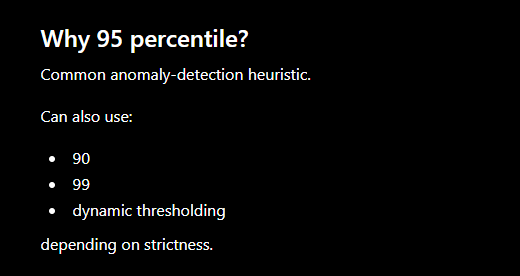

In [11]:
mse       = np.mean(np.power(X_normal - recon, 2), axis=1)

# 95th percentile = anything above this is anomaly
threshold = float(np.percentile(mse, 95))
joblib.dump(threshold, MODELS_DIR / 'threshold.pkl')

print(f'Mean reconstruction error  : {mse.mean():.6f}')
print(f'Threshold (95th percentile): {threshold:.6f}')
print('✅ Threshold saved')

Mean reconstruction error  : 0.414629
Threshold (95th percentile): 1.013105
✅ Threshold saved


## ✅ Training Complete

In [12]:
print('Models saved:')
for f in sorted(MODELS_DIR.iterdir()):
    print(f'  {f.name:<30} {f.stat().st_size / 1024:.1f} KB')
print('\n🚀 Run app.py to start the Flask server!')

Models saved:
  autoencoder.h5                 53.8 KB
  isolation_forest.pkl           600.7 KB
  lof.pkl                        4063.4 KB
  scaler.pkl                     1.3 KB
  threshold.pkl                  0.0 KB

🚀 Run app.py to start the Flask server!
